# From Red Flags to Detection Rules
## An LLM-driven Pipeline for Real-Time GOOSE Intrusion Detection and Prevention

> **Autores:** Lucas A. Martins¹*, Silvio E. Quincozes¹²  
> ¹ Universidade Federal de Uberlândia (UFU) – Uberlândia, Brasil  
> ² Universidade Federal do Pampa (UNIPAMPA) – Alegrete, Brasil  
> `{lucas.martins, sequincozes}@ufu.br`

---

### Resumo

Sistemas de Detecção de Intrusão (IDS) baseados em especificação são amplamente utilizados em subestações IEC 61850, mas dependem de regras criadas manualmente por especialistas. Este notebook apresenta um **pipeline orientado por LLM** que automatiza a geração de regras de detecção para detecção e prevenção de intrusões GOOSE em tempo real.

A abordagem utiliza amostras de comunicação rotuladas para identificar *red flags*, que são transformadas em regras de detecção de intrusão executáveis. A prova de conceito usa o **dataset ERENO** e demonstra que as regras geradas detectam comportamentos anômalos com baixo overhead operacional.

## Índice

1. [Introdução](#1-introdução)
2. [IDS Baseado em Especificação para GOOSE](#2-ids-baseado-em-especificação-para-goose)
3. [Arquitetura Proposta](#3-arquitetura-proposta)
4. [Instalação e Configuração do Ambiente](#4-instalação-e-configuração-do-ambiente)
5. [Ingestão de Dados (ERENO)](#5-ingestão-de-dados-ereno)
6. [Extração de Red Flags via LLM](#6-extração-de-red-flags-via-llm)
7. [Geração de Regras de Detecção](#7-geração-de-regras-de-detecção)
8. [Simulação do Switch Programável](#8-simulação-do-switch-programável)
9. [Avaliação: Capacidade de Detecção](#9-avaliação-capacidade-de-detecção)
10. [Avaliação: Viabilidade em Tempo Real](#10-avaliação-viabilidade-em-tempo-real)
11. [Considerações Finais](#11-considerações-finais)
12. [Referências](#12-referências)

---
## 1. Introdução

Subestações digitais baseadas no padrão **IEC–61850** enfrentam desafios crescentes de cibersegurança, incluindo ataques de:

- **Denial-of-Service (DoS)**
- **Injeção de mensagens (Message Injection)**
- **Mascaramento (Masquerade attacks)**

IDS baseados em especificação são atraentes nesse contexto por seu **baixo overhead computacional** e **interpretabilidade**. No entanto, dependem de regras escritas manualmente por especialistas — processo custoso, difícil de escalar e pouco adaptável.

**Motivação principal:** Automatizar a geração dessas regras usando LLMs a partir de amostras rotuladas do dataset ERENO–IEC–61850.

---
## 2. IDS Baseado em Especificação para GOOSE

O protocolo **GOOSE (Generic Object Oriented Substation Event)**, definido pelo padrão IEC–61850-8-1, suporta operações de proteção e controle em tempo crítico via modelo publisher/subscriber sobre Ethernet.

### Campos relevantes de um frame GOOSE

| Categoria | Campos |
|-----------|--------|
| Estruturais | `dst_mac`, `TPID`, `ethType`, `gooseAppid`, `timeAllowedToLive` |
| Consistência | `gocbRef`, `datSet`, `goID`, `t`, `stNum`, `sqNum` |
| Dinâmica | frequência de mensagens, bytes/s, pacotes/s |

> ⚠️ O GOOSE não foi projetado com mecanismos nativos de segurança robustos, tornando-o vulnerável a ataques de injeção, replay e negação de serviço.

---
## 3. Arquitetura Proposta

O pipeline é composto por **quatro estágios principais**:

```
┌─────────────────┐    ┌──────────────────┐    ┌───────────────────┐    ┌──────────────────┐
│  Dataset GOOSE  │───▶│ Red Flag Extract.│───▶│  Rule Generation  │───▶│ Switch Simulation│
│  Rotulado       │    │ (LLM-based)      │    │  (Python rules)   │    │  (Real-time)     │
│  (ERENO)        │    │                  │    │                   │    │                  │
└─────────────────┘    └──────────────────┘    └───────────────────┘    └──────────────────┘
```

| Estágio | Responsabilidade |
|---------|------------------|
| **1. Source Ingestion** | Carrega dataset, organiza features, prepara prompts estruturados |
| **2. Red Flag Extraction** | LLM identifica padrões suspeitos e inconsistências comportamentais |
| **3. Rule Generation** | Traduz red flags em regras Python executáveis |
| **4. Simulated Deployment** | Executa regras sobre tráfego GOOSE em tempo real simulado |

---
## 4. Instalação e Configuração do Ambiente

In [1]:
# Instalação das dependências (recomenda-se ambiente virtual)
!pip install -r requirements.txt

In [88]:
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd

from groq import Groq
from dotenv import load_dotenv

load_dotenv()  # carrega variáveis do .env na sessão

# api_key = os.getenv("GROQ_API_KEY")
api_key="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"


if not api_key:
    raise RuntimeError("Defina GROQ_API_KEY no arquivo .env.")

groq_client = Groq(api_key=api_key)
engine_model = "llama-3.1-8b-instant"


def get_groq_client():
    return groq_client

---
## 5. Ingestão de Dados (ERENO)

O dataset **ERENO–IEC–61850** fornece amostras rotuladas de tráfego GOOSE em condições normais e sob ataque.

Cada amostra contém features de três tipos:
- **Protocol-level:** campos do protocolo GOOSE
- **Temporal:** diferenças de timestamp entre mensagens
- **Derived:** métricas calculadas como `stDiff`, `sqDiff`, `timestampDiff`

In [94]:
from pathlib import Path

DATASET_PATH = Path("small_dataset/test.csv")

print("Dataset em:", DATASET_PATH.resolve())

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset não encontrado em {DATASET_PATH.resolve()}")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset carregado: {len(df)} amostras, {df.shape[1]} features\n")

# 1) Garante que TODAS as colunas importantes + 'class' sejam consideradas
IMPORTANT_COLUMNS = [
    "SqNum",
    "StNum",
    "cbStatus",
    # "ethType",
    # "gooseAppid",
    # "gooseLen",
    # "TPID",
    # "gocbRef",
    # "datSet",
    "goID",
    # "test",
    # "confRev",
    # "numDatSetEntries",
    # "APDUSize",
    "stDiff",
    "sqDiff",
    "gooseLengthDiff",
    "cbStatusDiff",
    "apduSizeDiff",
    "frameLengthDiff",
    "timestampDiff",
    "tDiff",
    "timeFromLastChange",
    "delay",
    "class" ## A classe é importante para o modelo aprender a distinguir ataques de tráfego normal, então deve ser mantida.
]

# 2) Garante que só usa colunas que existem de fato no df
available_cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
missing_cols = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

print("Colunas usadas no prompt:")
for c in available_cols:
    print(" -", c)

if missing_cols:
    print("\n[Aviso] Colunas não encontradas no dataset e ignoradas:")
    for c in missing_cols:
        print(" -", c)

# 3) Cria df_reduced COM APENAS essas colunas (todo o resto é removido)
df_reduced = df[available_cols].copy()
print(f"\nDataset reduzido: {len(df_reduced)} amostras, {df_reduced.shape[1]} features\n")

# 4) Confirmar que só sobraram colunas importantes + class:
print("Colunas finais em df_reduced:")
for col in df_reduced.columns:
    print(" -", col)

print("Primeiras linhas:")
display(df_reduced.head())


Dataset em: /home/camilla/sbrc/SBRC_2026/small_dataset/test.csv
Dataset carregado: 793 amostras, 52 features

Colunas usadas no prompt:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class

Dataset reduzido: 793 amostras, 15 features

Colunas finais em df_reduced:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class
Primeiras linhas:


,SqNum,StNum,cbStatus,goID,stDiff,sqDiff,gooseLengthDiff,cbStatusDiff,apduSizeDiff,frameLengthDiff,timestampDiff,tDiff,timeFromLastChange,delay,class
0,75.0,32623.0,0.0,IntLockA,31940.0,-6.0,0.0,0.0,0.0,0.0,0.140944,85.427032,0.000000,0.000139,high_StNum
1,100.0,48.0,0.0,IntLockA,8.0,51.0,0.0,1.0,0.0,0.0,0.078334,139.756634,-97.275946,0.000189,injection
2,6.0,189.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.042939,0.000000,1.891003,0.000243,random_replay
3,25.0,509.0,0.0,IntLockA,0.0,1.0,0.0,0.0,0.0,0.0,0.037362,0.000000,20.479475,0.000335,normal
4,1.0,6519.0,1.0,IntLockA,1.0,0.0,0.0,0.0,0.0,0.0,6.070178,0.000000,39077.578326,0.000198,poisoned_high_rate


## 6. Geração de Regras de Detecção (de maneira otimizada)

In [96]:
import time
import json
from pathlib import Path

import pandas as pd
from groq import RateLimitError


# 1. Selecionar amostras normais e por classe
def sample_normal_and_attacks(
    df: pd.DataFrame,
    n_normal: int = 20,
    n_per_attack: int = 10,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Separa um pequeno conjunto de referência normal e amostras por classe de ataque.
    Assume que df['class'] == 'normal' para tráfego legítimo e outros valores são ataques.
    """
    df_normal = df[df["class"] == "normal"].sample(
        n=min(n_normal, (df["class"] == "normal").sum()),
        random_state=42,
    )

    attack_classes = sorted(c for c in df["class"].unique() if c != "normal")
    attack_samples: dict[str, pd.DataFrame] = {}

    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        attack_samples[cls] = df_cls.sample(
            n=min(n_per_attack, len(df_cls)),
            random_state=42,
        )

    return df_normal, attack_samples


# 2. Prompt base com “referência normal”
def make_normal_reference_block(df_normal: pd.DataFrame) -> str:
    header = (
        "Você é um especialista em segurança de subestações IEC 61850.\n"
        "Abaixo estão amostras de tráfego GOOSE normal; use-as como referência\n"
        "de comportamento legítimo. A coluna 'class' sempre é 'normal'.\n\n"
        "=== AMOSTRAS NORMAIS (REFERÊNCIA) ===\n"
    )
    return header + df_normal.to_string(index=False)


# 3. Prompt por classe de ataque para gerar regras incrementais
def make_attack_prompt_for_rules(
    df_normal_ref: pd.DataFrame,
    df_attack: pd.DataFrame,
    attack_class: str,
) -> str:
    """
    Cria um prompt compacto para uma classe de ataque específica,
    reutilizando a mesma referência de tráfego normal.
    """
    normal_block = make_normal_reference_block(df_normal_ref)

    attack_block = (
        f"\n\n=== AMOSTRAS DE ATAQUE: {attack_class} ===\n"
        + df_attack.to_string(index=False)
    )

    instructions = f"""
        Você é um modelo especializado em detecção de intrusões em tráfego IEC 61850-GOOSE.

        Tarefa:
        A partir da diferença entre amostras NORMAIS (referência) e amostras de ataque da classe '{attack_class}', gere FUNÇÕES DE REGRAS DE DETECÇÃO em Python para identificar pacotes suspeitos dessa classe.

        Regras de saída:

        Retorne APENAS código Python válido, sem explicações, comentários extras ou markdown.

        Crie de 3 a 5 funções com a forma:

        def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
        \"\"\"Retorna True se o pacote for suspeito desse ataque.\"\"\"
        # lógica usando apenas campos presentes em packet
        ...

        Use nomes_curto descritivos em snake_case (ex.: jumps_stnum_time_diff, sqnum_reset_pattern).

        Restrições:

        NÃO use a coluna/atributo \"class\" em hipótese alguma (assuma que packet não tem essa chave).

        Use apenas campos que existem no dataset, como por exemplo: 'StNum', 'SqNum', 'timestampDiff', 'cbStatus', 'ethSrc', 'ethDst', 'appID', flags e contadores.

        Cada regra deve combinar DOIS OU MAIS campos (evite depender de um campo único).

        NÃO use igualdade exata para valores específicos de timestamp, StNum ou SqNum (evite “== 42” ou “== 0.1234”).

        PREFIRA condições relativas e comportamentais, por exemplo:

        Comparações de maior/menor (timestampDiff muito maior ou muito menor que o normal).

        Diferenças entre contadores ou campos derivados (ex.: timestampDiff, stNumDiff, sqNumDiff).

        Padrões de origem/destino (ethSrc/ethDst) combinados com mudanças em StNum/SqNum.

        Foque em captar o comportamento típico da classe '{attack_class}' em contraste com o tráfego normal (replay, jumps anômalos, resets inesperados, frequência anômala, etc.).

        Estilo do código:

        Use apenas operações básicas de Python (comparações, AND/OR/NOT, soma/subtração).

        Não importe bibliotecas.

        Se precisar, trate campos ausentes com packet.get(\"campo\", valor_padrao).

        Agora gere as funções de regra em Python para a classe '{attack_class}' seguindo estritamente estas instruções.
"""


# Com base na diferença entre as amostras NORMAIS (referência)
# e as amostras da classe de ataque '{attack_class}', gere funções
# DE REGRAS DE DETECÇÃO em Python.

# Requisitos:
# - Retorne APENAS código Python válido, sem explicações ou markdown.
# - Cada regra deve ter a forma:

# def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
#     \"\"\"Retorna True se o pacote for suspeito desse ataque.\"\"\"
#     # lógica usando campos como 'StNum', 'SqNum', 'timestampDiff', etc.

# - Use apenas campos presentes nas tabelas (colunas do dataset) mas 
#  JAMAIS UTILIZE A COLUNA CLASS, pois ela é apenas para referência 
#  e para que você consiga distinguir normal de ataque.
# - Foque nas condições que distinguem '{attack_class}' do tráfego normal, EXCETO (OBVIAMENTE) PELA COLUNA "class"
# - Procure sempre combinar mais de um campo para criar regras mais robustas, ao invés de depender de um único campo.
# - Evite criar regras que superespecializam demais (ex. usar uma condição de igualdade para timestamp, numero de estado ou sequencia, por exemplo).
# - Foque em regras que capturem o comportamento anômalo de '{attack_class}' sem depender de valores específicos de timestamp, numero de estado ou sequencia, por exemplo. Ao invés disso, você pode combinar campos diferentes ou usar condições de maior/menor, por exemplo, ou usar diferenças entre campos (ex. timestampDiff > 100ms) ao invés de valores absolutos.
# """
    return normal_block + attack_block + instructions


# 4. Append em rules.py
def append_rules_to_file(code_text: str, filename: str = "rules.py") -> Path:
    """
    Acrescenta novas regras ao arquivo rules.py (cria se não existir).
    """

    if code_text.startswith("```"):
        code_text = code_text.strip("`")
        # remove possíveis prefixos como "python\n"
        if code_text.lower().startswith("python"):
            code_text = code_text[len("python"):].lstrip()

    path = Path(filename).resolve()
    mode = "a" if path.exists() else "w"
    with path.open(mode, encoding="utf-8") as f:
        if mode == "a":
            f.write("\n\n")
        f.write(code_text.strip() + "\n")
    print(f"Regras adicionadas em: {path}")
    return path


# 5. Wrapper com backoff dinâmico para RateLimitError
def call_llm_for_rules_with_retry(
    prompt: str,
    model: str = "groq/compound",
    max_retries: int = 5,
) -> str:
    """
    Chama o LLM para gerar código de regras, tratando RateLimitError
    com espera dinâmica baseada na mensagem da API.
    """
    client = get_groq_client()

    system_msg = (
        "Você é um especialista em segurança IEC 61850 e desenvolvedor Python. "
        "Dado o contexto e as red flags, você deve retornar SOMENTE código "
        "Python válido. Não inclua explicações, texto em linguagem natural "
        "ou markdown. Apenas código Python puro."
    )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": prompt},
    ]

    attempt = 0
    while True:
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,
                max_completion_tokens=2048,
                top_p=1,
            )
            code_text = completion.choices[0].message.content.strip()
            if code_text.startswith("```"):
                code_text = code_text.strip("`")
                if code_text.lower().startswith("python"):
                    code_text = code_text[len("python"):].lstrip()
            return code_text

        except RateLimitError as e:
            attempt += 1
            if attempt > max_retries:
                print("[RateLimit] Número máximo de tentativas excedido.")
                raise

            # valor padrão se não conseguirmos extrair da mensagem
            wait_seconds = min(60.0, 2 ** attempt)

            try:
                msg = str(e)
                marker = "Please try again in "
                if marker in msg and "s." in msg:
                    fragment = msg.split(marker, 1)[1]
                    seconds_str = fragment.split("s", 1)
                    wait_seconds = float(seconds_str)
            except Exception:
                pass  # fica com o backoff exponencial

            print(
                f"[RateLimit] Aguardando {wait_seconds:.2f}s antes de tentar "
                f"novamente (tentativa {attempt}/{max_retries})..."
            )
            time.sleep(wait_seconds)


# 6. Pipeline de geração incremental de regras
df_normal_ref, attack_samples = sample_normal_and_attacks(
    df_reduced, 
    n_normal=20,
    n_per_attack=10,
)

for attack_class, df_attack in attack_samples.items():
    print(f"\n=== Gerando regras para classe: {attack_class} ===")
    prompt_attack = make_attack_prompt_for_rules(df_normal_ref, df_attack, attack_class)

    code_rules = call_llm_for_rules_with_retry(
        prompt_attack,
        model=engine_model,
        max_retries=5,
    )

    append_rules_to_file(f"## {attack_class}", filename="rules.py")
    append_rules_to_file(code_rules, filename="rules.py")



=== Gerando regras para classe: grayhole ===
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py

=== Gerando regras para classe: high_StNum ===
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py

=== Gerando regras para classe: injection ===
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py

=== Gerando regras para classe: inverse_replay ===
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py

=== Gerando regras para classe: masquerade_fake_fault ===
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py

=== Gerando regras para classe: masquerade_fake_normal ===
Regras adicionadas em: /home/camilla/sbrc/SBRC_2026/rules.py
Regras adicionada

## 7. Execuçao das regras (rules.py) e registro de resultados

In [98]:
from pathlib import Path
import pandas as pd
import rules as rules  # rules.py gerado pelo LLM

def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")

    df = pd.read_csv(csv_path)

    # Garante que só usamos as colunas disponíveis
    cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

    print("Colunas usadas na análise:")
    for c in cols:
        print(" -", c)

    if missing:
        print("\n[Aviso] Colunas ausentes no CSV (ignoradas):")
        for c in missing:
            print(" -", c)

    return df[cols].copy()


def row_to_packet(row: pd.Series) -> dict:
    """
    Converte uma linha do DataFrame em um dicionário `packet`
    para ser passado às funções de regra em rules.py.
    """
    return row.to_dict()


def apply_rules_to_csv(csv_path: str | Path) -> pd.DataFrame:
    """
    Lê um CSV GOOSE, aplica as regras de rules.py a cada linha
    e retorna um DataFrame com colunas extras indicando violações.
    """
    df = load_goose_csv(csv_path)

    # Descobre todas as funções rule_* definidas em rules.py
    rule_functions = {
        name: fn
        for name, fn in vars(rules).items()
        if callable(fn) and name.startswith("rule_")
    }

    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("\nRegras encontradas:")
    for name in rule_functions:
        print(" -", name)

    # Para cada regra, criamos uma coluna booleana
    for rule_name, rule_fn in rule_functions.items():
        results = []
        for _, row in df.iterrows():
            packet = row_to_packet(row)
            try:
                violated = bool(rule_fn(packet))
            except Exception:
                # Em caso de erro na regra, marque como False
                violated = False
            results.append(violated)
        df[rule_name] = results

    # Coluna geral “decision” (BLOCK se qualquer regra acusar)
    df["any_rule_violation"] = df[[r for r in rule_functions]].any(axis=1)
    df["decision"] = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})

    return df


def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma matriz de confusão por classe real, considerando:
    - Positivo = ataque (qualquer class != 'normal'), decision = BLOCK
    - Negativo = normal (class == 'normal'), decision = ALLOW

    A matriz resultante tem, para cada classe real:
    TP, FP, TN, FN e métricas derivadas.
    """
    if "class" not in df.columns or "decision" not in df.columns:
        raise ValueError("DataFrame precisa das colunas 'class' e 'decision'.")

    classes = sorted(df["class"].unique())
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]

        if cls == "normal":
            # normal é negativo (esperado ALLOW)
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = 0
            fn = 0
        else:
            # ataques são positivos (esperado BLOCK)
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            # FP/TN contam impacto em outras classes; aqui deixamos 0 por classe
            fp = 0
            tn = 0

        total = len(df_cls)
        tpr = tp / total if total > 0 else 0.0  # recall para essa classe
        fpr = fp / total if total > 0 else 0.0

        records.append(
            {
                "class": cls,
                "support": total,
                "TP": tp,
                "FP": fp,
                "TN": tn,
                "FN": fn,
                "TPR_recall": tpr,
                "FPR": fpr,
            }
        )

    return pd.DataFrame(records)


# Exemplo de uso
if __name__ == "__main__":
    # analyzed_df = apply_rules_to_csv("small_dataset/test.csv")
    analyzed_df = apply_rules_to_csv("/home/camilla/Transferências/ERENO-2.0-100K.csv")
    print("\nResumo das decisões globais:")
    print(analyzed_df["decision"].value_counts())

    print("\nMatriz de confusão por classe:")
    cm_df = confusion_matrix_per_class(analyzed_df)
    print(cm_df.to_string(index=False))


Colunas usadas na análise:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class

Regras encontradas:
 - rule_grayhole_stnum
 - rule_grayhole_sqnum
 - rule_grayhole_timediff
 - rule_grayhole_goose_length
 - rule_grayhole_apdu_size
 - rule_grayhole_frame_length
 - rule_grayhole_combined
 - rule_high_StNum_StNum
 - rule_high_StNum_stDiff
 - rule_high_StNum_stDiff_and_StNum
 - rule_high_StNum_timeFromLastChange
 - rule_high_StNum_combined
 - rule_injection_stdiff
 - rule_injection_sqdiff
 - rule_injection_timestampdiff
 - rule_injection_tdiff
 - rule_injection_timefromlastchange
 - rule_injection_combined
 - rule_inverse_replay_stnum
 - rule_inverse_replay_sqnum
 - rule_inverse_replay_tdiff
 - rule_inverse_replay_stdiff_sqdiff
 - rule_inverse_replay_combined
 - rule_masquerade_fake_fault_tdiff
 - rule_masquerade_fake_fault_timestampdiff
 - rule_masque

---
## 8. Geração de matriz

In [101]:
### ESTE CÓDIGO SUBSTITUI OS PRÓXIMOS DOIS BLOCOS
"""
pipeline_regras.py
==================
Pipeline unificado para:
  1. Carregar rules.py com auto-correção de SyntaxError (importlib)
  2. Aplicar as regras ao CSV GOOSE → decision BLOCK/ALLOW
  3. Gerar matriz de confusão por classe
  4. Gerar matriz regra × classe de ataque (contagens de disparos)
  5. Gerar detecções por amostra (CSV)
  6. Gerar detecções agregadas por classe (CSV)
  7. Medir latência por regra (CSV)
"""

from __future__ import annotations

import importlib.util
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd

# ── Ajuste os caminhos e parâmetros aqui ──────────────────────────
CSV_PATH   = "/home/camilla/Transferências/ERENO-2.0-100K.csv" #small_dataset/test.csv" #
RULES_PATH = "rules.py"
N_RUNS     = 1   # repetições por pacote para medição de latência
# ──────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────
# 1. Carregamento do rules.py com auto-correção de SyntaxError
# ─────────────────────────────────────────────────────────────────

def load_rules_with_cleanup(path: str | Path):
    """
    Carrega rules.py via importlib.
    Se houver SyntaxError, remove a linha inválida e tenta novamente.
    """
    path = str(path)
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod  = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise
            print(f"  Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            del lines[idx]
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
        except Exception:
            traceback.print_exc()
            raise


# ─────────────────────────────────────────────────────────────────
# 2. Leitura do CSV
# ─────────────────────────────────────────────────────────────────

def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")

    df = pd.read_csv(csv_path)

    cols    = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

    print("Colunas usadas na análise:")
    for c in cols:
        print(" -", c)

    if missing:
        print("\n[Aviso] Colunas ausentes no CSV (ignoradas):")
        for c in missing:
            print(" -", c)

    df = df[cols].copy()
    # Normaliza a coluna class para evitar mixed-type no sorted()
    if "class" in df.columns:
        df["class"] = df["class"].astype(str)

    return df


# ─────────────────────────────────────────────────────────────────
# 3. Aplicação das regras → colunas booleanas + decision
# ─────────────────────────────────────────────────────────────────

def apply_rules(df: pd.DataFrame, rule_functions: dict) -> pd.DataFrame:
    """
    Aplica todas as funções rule_* ao DataFrame.
    Adiciona uma coluna booleana por regra e as colunas
    any_rule_violation e decision (BLOCK / ALLOW).
    """
    # Avalia cada regra uma única vez por amostra
    rule_results: dict[str, list[bool]] = {name: [] for name in rule_functions}

    for _, row in df.iterrows():
        pkt = row.to_dict()
        for name, fn in rule_functions.items():
            try:
                rule_results[name].append(bool(fn(pkt)))
            except Exception:
                rule_results[name].append(False)

    for name, results in rule_results.items():
        df[name] = results

    df["any_rule_violation"] = df[list(rule_functions)].any(axis=1)
    df["decision"]           = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})

    return df


# ─────────────────────────────────────────────────────────────────
# 4. Matriz de confusão por classe
# ─────────────────────────────────────────────────────────────────

def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera métricas TP/FP/TN/FN por classe real:
      - normal  → negativo (esperado ALLOW)
      - demais  → positivo (esperado BLOCK)
    """
    if "class" not in df.columns or "decision" not in df.columns:
        raise ValueError("DataFrame precisa das colunas 'class' e 'decision'.")

    classes = sorted(df["class"].unique())
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]

        if cls == "normal":
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = fn = 0
        else:
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            fp = tn = 0

        total = len(df_cls)
        tpr   = tp / total if total > 0 else 0.0
        fpr   = fp / total if total > 0 else 0.0

        records.append({
            "class":      cls,
            "support":    total,
            "TP":         tp,
            "FP":         fp,
            "TN":         tn,
            "FN":         fn,
            "TPR_recall": tpr,
            "FPR":        fpr,
        })

    return pd.DataFrame(records)


# ─────────────────────────────────────────────────────────────────
# 5. Matriz regra × classe de ataque (contagens de disparos)
# ─────────────────────────────────────────────────────────────────

def build_rule_class_matrix(df: pd.DataFrame,
                             rule_functions: dict,
                             attack_classes: list[str]) -> pd.DataFrame:
    """
    Retorna um DataFrame (regras × classes) com o número de vezes
    que cada regra disparou para amostras de cada classe.
    Reutiliza as colunas booleanas já calculadas em apply_rules().
    """
    records = []
    for rule_name in rule_functions:
        row = {"Regra": rule_name}
        for cls in attack_classes:
            df_cls  = df[df["class"] == cls]
            row[cls] = int(df_cls[rule_name].sum()) if rule_name in df_cls.columns else 0
        records.append(row)

    return pd.DataFrame(records).set_index("Regra")


# ─────────────────────────────────────────────────────────────────
# 6. Detecções por amostra e agregado por classe
# ─────────────────────────────────────────────────────────────────

def build_sample_and_class_detections(df: pd.DataFrame,
                                       rule_functions: dict,
                                       attack_classes: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Retorna:
      df_por_amostra    – uma linha por amostra; para cada classe: 1 se
                          qualquer regra_<classe> disparou, 0 caso contrário.
      df_agregado       – uma linha por classe verdadeira; soma das
                          detecções de cada "coluna de classe" nessa fatia.

    Reutiliza os resultados de apply_rules() (colunas booleanas já presentes).
    """
    # Mapa: nome_da_classe → [nomes de regras que contêm esse nome]
    rules_by_class = {
        cls: [name for name in rule_functions if cls in name]
        for cls in attack_classes
    }

    sample_records = []
    for idx, row in df.iterrows():
        sample_row = {
            "sample_index": idx,
            "true_class":   row.get("class", None),
        }
        for cls in attack_classes:
            fired = any(bool(row.get(rname, False)) for rname in rules_by_class[cls])
            sample_row[cls] = int(fired)
        sample_records.append(sample_row)

    df_por_amostra = pd.DataFrame(sample_records)

    # Agregado por classe verdadeira
    class_cols = list(attack_classes)
    agregado_records = []
    for cls in attack_classes:
        df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
        row_agg = {col: int(df_cls_samples[col].sum()) for col in class_cols}
        row_agg["classe_ataque"] = cls
        agregado_records.append(row_agg)

    df_agregado = pd.DataFrame(agregado_records).set_index("classe_ataque")

    return df_por_amostra, df_agregado


# ─────────────────────────────────────────────────────────────────
# 7. Latência por regra
# ─────────────────────────────────────────────────────────────────

def measure_latency(df: pd.DataFrame,
                    rule_functions: dict,
                    n_runs: int = 1) -> pd.DataFrame:
    """
    Mede a latência de execução (µs) de cada regra sobre todos os pacotes.
    """
    packets = [row.to_dict() for _, row in df.iterrows()]
    records = []

    for rule_name, rule_fn in rule_functions.items():
        latencies = []
        for _ in range(n_runs):
            for pkt in packets:
                t0 = time.perf_counter()
                try:
                    rule_fn(pkt)
                except Exception:
                    pass
                latencies.append((time.perf_counter() - t0) * 1e6)

        arr = np.array(latencies)
        records.append({
            "Regra":      rule_name,
            "Média (µs)": round(np.mean(arr),            4),
            "DP (µs)":    round(np.std(arr),             4),
            "Min (µs)":   round(np.min(arr),             4),
            "Max (µs)":   round(np.max(arr),             4),
            "P99 (µs)":   round(np.percentile(arr, 99),  4),
        })

    return pd.DataFrame(records).sort_values("Média (µs)")


# ─────────────────────────────────────────────────────────────────
# Ponto de entrada principal
# ─────────────────────────────────────────────────────────────────

def run_pipeline(csv_path: str | Path = CSV_PATH,
                 rules_path: str | Path = RULES_PATH,
                 n_runs: int = N_RUNS) -> None:

    # ── 1. Carrega regras ────────────────────────────────────────
    mod = load_rules_with_cleanup(rules_path)
    rule_functions = {
        name: fn for name, fn in vars(mod).items()
        if callable(fn) and name.startswith("rule_")
    }
    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("Regras carregadas:")
    for name in rule_functions:
        print(" -", name)

    # ── 2. Lê o CSV ─────────────────────────────────────────────
    df = load_goose_csv(csv_path)
    attack_classes = sorted(c for c in df["class"].dropna().unique() if c != "normal")
    print(f"\nDataset: {len(df)} amostras | classes: {['normal'] + attack_classes}")

    # ── 3. Aplica regras (loop único por amostra) ────────────────
    print("\nAplicando regras…")
    df = apply_rules(df, rule_functions)

    # ── 4. Resumo e matriz de confusão ───────────────────────────
    print("\nResumo das decisões globais:")
    print(df["decision"].value_counts())

    print("\nMatriz de confusão por classe:")
    cm_df = confusion_matrix_per_class(df)
    print(cm_df.to_string(index=False))

    # ── 5. Matriz regra × classe ─────────────────────────────────
    matrix_df = build_rule_class_matrix(df, rule_functions, attack_classes)
    matrix_df.to_csv("matriz_regras_ataques.csv")
    print("\n✓ Matriz regra × classe salva em: matriz_regras_ataques.csv")

    # ── 6. Detecções por amostra e agregado por classe ───────────
    df_por_amostra, df_agregado = build_sample_and_class_detections(
        df, rule_functions, attack_classes
    )
    df_por_amostra.to_csv("deteccoes_por_amostra.csv", index=False)
    df_agregado.to_csv("deteccoes_agregado_classes.csv")
    print("✓ Detecções por amostra salvas em: deteccoes_por_amostra.csv")
    print("✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv")

    # ── 7. Latência ──────────────────────────────────────────────
    print("\nMedindo latência por regra…")
    df_latency = measure_latency(df, rule_functions, n_runs=n_runs)
    df_latency.to_csv("latencia_regras.csv", index=False)
    print("✓ Latência salva em: latencia_regras.csv")

    # Exibe tabelas se estiver num ambiente notebook
    try:
        from IPython.display import display
        display(matrix_df)
        display(df_por_amostra)
        display(df_agregado)
        display(df_latency)
    except ImportError:
        print(matrix_df)
        print(df_por_amostra.head())
        print(df_agregado)
        print(df_latency)


if __name__ == "__main__":
    run_pipeline()

Regras carregadas:
 - rule_grayhole_jumps_stnum_time_diff
 - rule_grayhole_sqnum_reset_pattern
 - rule_grayhole_stnum_jumps
 - rule_grayhole_timestamp_diff
 - rule_grayhole_cbstatus_diff
 - rule_high_StNum_jumps_stnum_time_diff
 - rule_high_StNum_sqnum_reset_pattern
 - rule_high_StNum_stnum_diff
 - rule_high_StNum_timestamp_diff
 - rule_high_StNum_eth_src_dst
 - rule_injection_jumps_stnum_time_diff
 - rule_injection_sqnum_reset_pattern
 - rule_injection_stnum_jumps_time_diff
 - rule_injection_cbstatus_diff
 - rule_injection_ethsrc_dst_diff
 - rule_inverse_replay_jumps_stnum_time_diff
 - rule_inverse_replay_sqnum_reset_pattern
 - rule_inverse_replay_cbstatus_diff_pattern
 - rule_inverse_replay_ethsrc_dst_pattern
 - rule_inverse_replay_appid_diff_pattern
 - rule_masquerade_fake_fault_jumps_stnum_time_diff
 - rule_masquerade_fake_fault_sqnum_reset_pattern
 - rule_masquerade_fake_fault_src_dst_pattern
 - rule_masquerade_fake_fault_cbstatus_diff
 - rule_masquerade_fake_fault_stnum_diff
 - r

,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
Regra,,,,,,,,
rule_grayhole_jumps_stnum_time_diff,1850,4398,0,0,365,1613,0,5804
rule_grayhole_sqnum_reset_pattern,2,0,0,0,2,0,2,1
rule_grayhole_stnum_jumps,1480,6471,0,0,0,1710,0,3127
rule_grayhole_timestamp_diff,946,3828,3849,0,6798,0,18516,3382
rule_grayhole_cbstatus_diff,1001,4470,5742,0,4362,172,509,3810
rule_high_StNum_jumps_stnum_time_diff,0,7831,0,0,0,0,2,0
rule_high_StNum_sqnum_reset_pattern,0,1,0,0,0,0,0,0
rule_high_StNum_stnum_diff,0,18128,0,0,0,0,0,0
rule_high_StNum_timestamp_diff,184,4185,4321,0,640,0,0,561


,sample_index,true_class,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
0,0,grayhole,0,0,0,0,0,1,0,0
1,1,normal,0,0,0,0,0,1,0,0
2,2,injection,1,1,1,0,1,1,0,1
3,3,high_StNum,1,1,1,1,1,1,0,1
4,4,high_StNum,1,1,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...
199993,199993,poisoned_high_rate,1,0,0,1,1,1,0,1
199994,199994,poisoned_high_rate,1,0,0,1,1,1,0,1
199995,199995,poisoned_high_rate,1,0,0,1,1,1,0,1
199996,199996,poisoned_high_rate,1,0,0,1,1,1,0,1


,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,poisoned_high_rate,random_replay
classe_ataque,,,,,,,,
grayhole,2389,184,1517,2839,1367,19999,0,3411
high_StNum,9733,18519,14021,10560,8611,20000,0,14250
injection,7040,4321,9072,2705,13322,20000,0,13884
inverse_replay,0,0,142,705,1045,20000,0,4836
masquerade_fake_fault,9140,640,3355,8844,10800,20000,0,13360
masquerade_fake_normal,2078,0,693,2621,0,20000,0,7279
poisoned_high_rate,18757,2,1228,18886,18801,20000,0,19378
random_replay,8259,561,5340,10406,4772,20000,0,14667


,Regra,Média (µs),DP (µs),Min (µs),Max (µs),P99 (µs)
18,rule_inverse_replay_ethsrc_dst_pattern,0.1982,0.5257,0.110,144.591,0.9120
22,rule_masquerade_fake_fault_src_dst_pattern,0.1994,0.4194,0.110,40.096,0.9220
38,rule_random_replay_timestamp_diff,0.2238,0.4348,0.114,38.317,0.9470
19,rule_inverse_replay_appid_diff_pattern,0.2440,3.5189,0.110,738.059,0.9380
29,rule_masquerade_fake_normal_appid_diff,0.2630,3.7127,0.107,719.119,0.9520
36,rule_random_replay_sqnum_reset_pattern,0.2642,0.6820,0.113,161.328,0.9820
16,rule_inverse_replay_sqnum_reset_pattern,0.2695,0.8784,0.118,167.267,0.9770
26,rule_masquerade_fake_normal_sqnum_reset_pattern,0.2807,0.8760,0.117,250.628,1.0670
25,rule_masquerade_fake_normal_jumps_stnum_time_diff,0.2928,0.5933,0.123,114.877,1.1470
6,rule_high_StNum_sqnum_reset_pattern,0.2991,3.0525,0.118,725.469,0.9970


In [72]:
import importlib.util
import pandas as pd
import time
import numpy as np
import traceback


# ── Ajuste os caminhos aqui ──────────────────────────────────────
CSV_PATH   = "/home/camilla/Transferências/ERENO-2.0-100K.csv"
RULES_PATH = "rules.py"
OUTPUT     = "matriz_regras_ataques.csv"
N_RUNS     = 1   # repetições por pacote
# ────────────────────────────────────────────────────────────────



def load_rules_with_cleanup(path):
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            # Lê o arquivo
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            # Garante índice válido
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise


            print(f"Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            # Remove a linha inválida
            del lines[idx]
            # Salva de volta
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
            # Loop continua e tenta carregar de novo
        except Exception:
            traceback.print_exc()
            raise


RULES_PATH = "rules.py"
mod = load_rules_with_cleanup(RULES_PATH)


rule_functions = {
    name: fn for name, fn in vars(mod).items()
    if callable(fn) and name.startswith("rule_")
}
print("Regras carregadas:", list(rule_functions.keys()))
# Carrega dataset
df = pd.read_csv(CSV_PATH)
cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
df = df[cols].copy()
print(f"Dataset: {len(df)} amostras | classes: {sorted(df['class'].dropna().unique())}")


# Monta a matriz
attack_classes = sorted(df["class"].dropna().unique())
records = []
for rule_name, rule_fn in rule_functions.items():
    row = {"Regra": rule_name}
    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        count = sum(
            1 for _, r in df_cls.iterrows()
            if rule_fn(r.to_dict())
        )
        row[cls] = count
    records.append(row)


matrix_df = pd.DataFrame(records).set_index("Regra")
matrix_df.to_csv(OUTPUT)
print(f"\n✓ Matriz salva em: {OUTPUT}")
display(matrix_df)


# ── Detecções por amostra e agregado por classe ──────────────────

# Monta dicionário {classe: [rule_fn, ...]} associando regras às classes pelo nome
rules_by_class = {
    cls: [fn for name, fn in rule_functions.items() if cls in name]
    for cls in attack_classes
}
print("\nRegras por classe:")
for cls, fns in rules_by_class.items():
    print(f"  {cls}: {[name for name in rule_functions if cls in name]}")

# Importa tqdm se disponível
try:
    from tqdm import tqdm
    _iter = lambda iterable, **kw: tqdm(iterable, **kw)
except ImportError:
    _iter = lambda iterable, **kw: iterable

# CSV por amostra ─────────────────────────────────────────────────
# Uma linha por amostra. Colunas: sample_index, true_class, <classe_1>, <classe_2>, ...
# Cada célula de classe = 1 se QUALQUER regra associada disparou, 0 caso contrário.
# Avalia todas as regras uma única vez por amostra para eficiência.
sample_records = []
for idx, row in _iter(df.iterrows(), desc="Detecções por amostra", total=len(df)):
    pkt = row.to_dict()

    # Avalia cada rule_function uma única vez
    rule_results = {name: False for name in rule_functions}
    for name, fn in rule_functions.items():
        try:
            rule_results[name] = bool(fn(pkt))
        except Exception:
            rule_results[name] = False

    sample_row = {
        "sample_index": idx,
        "true_class": pkt.get("class", None),
    }
    for cls in attack_classes:
        # Detecção = 1 se qualquer regra da classe disparou
        fired = any(
            rule_results[name]
            for name in rule_functions
            if cls in name
        )
        sample_row[cls] = int(fired)

    sample_records.append(sample_row)

df_por_amostra = pd.DataFrame(sample_records)
df_por_amostra.to_csv("deteccoes_por_amostra.csv", index=False)
print(f"✓ Detecções por amostra salvas em: deteccoes_por_amostra.csv")
display(df_por_amostra)

# CSV agregado por classe ─────────────────────────────────────────
# Uma linha por classe de ataque (indice = nome da classe).
# Colunas = classes de ataque.
# Cada célula [linha_cls][col_cls] = número de amostras em que qualquer regra
# da col_cls detectou ataque, contando apenas amostras cuja true_class == linha_cls.
class_cols = list(attack_classes)

agregado_records = []
for cls in attack_classes:
    # Filtra apenas amostras cuja classe verdadeira é cls
    df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
    row = {col: int(df_cls_samples[col].sum()) for col in class_cols}
    row["classe_ataque"] = cls
    agregado_records.append(row)

df_agregado_classes = pd.DataFrame(agregado_records).set_index("classe_ataque")
df_agregado_classes.to_csv("deteccoes_agregado_classes.csv")
print(f"✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv")
display(df_agregado_classes)

# ── Latência por regra ───────────────────────────────────────────
print("\nMedindo latência por regra...")
packets = [row.to_dict() for _, row in df.iterrows()]


latency_records = []
for rule_name, rule_fn in rule_functions.items():
    latencies = []
    for _ in range(N_RUNS):
        for pkt in packets:
            t0 = time.perf_counter()
            try:
                rule_fn(pkt)
            except Exception:
                pass
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1e6)  # microsegundos


    latencies = np.array(latencies)
    latency_records.append({
        "Regra":      rule_name,
        "Média (µs)": round(np.mean(latencies), 4),
        "DP (µs)":    round(np.std(latencies),  4),
        "Min (µs)":   round(np.min(latencies),  4),
        "Max (µs)":   round(np.max(latencies),  4),
        "P99 (µs)":   round(np.percentile(latencies, 99), 4),
    })


df_latency = pd.DataFrame(latency_records).sort_values("Média (µs)")
df_latency.to_csv("latencia_regras.csv", index=False)
print("✓ Latência salva em: latencia_regras.csv")
display(df_latency)


Regras carregadas: ['rule_grayhole_timestamp_diff', 'rule_grayhole_st_diff', 'rule_grayhole_sq_diff', 'rule_grayhole_cb_status', 'rule_grayhole_class', 'rule_grayhole_time_from_last_change', 'rule_grayhole_delay', 'rule_grayhole_suspicious', 'rule_high_StNum_StNum', 'rule_high_StNum_SqNum', 'rule_high_StNum_timestampDiff', 'rule_high_StNum_StDiff', 'rule_high_StNum_SqDiff', 'rule_high_StNum_goosLengthDiff', 'rule_high_StNum_cbStatusDiff', 'rule_high_StNum_apduSizeDiff', 'rule_high_StNum_frameLengthDiff', 'rule_high_StNum_timeFromLastChange', 'rule_high_StNum_delay', 'rule_injection_st_diff', 'rule_injection_sq_diff', 'rule_injection_cb_status', 'rule_injection_timestamp_diff', 'rule_injection_time_from_last_change', 'rule_injection_delay', 'rule_injection_class', 'rule_injection_st_num', 'rule_injection_sq_num', 'rule_injection_cb_status_diff', 'rule_injection_apdu_size_diff', 'rule_injection_frame_length_diff', 'rule_inverse_replay_timestamp_diff', 'rule_inverse_replay_st_num', 'rule_

,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,normal,poisoned_high_rate,random_replay
Regra,,,,,,,,,
rule_grayhole_timestamp_diff,2836,12890,12916,3811,13095,2311,18068,19378,11948
rule_grayhole_st_diff,2792,19998,14447,14150,12823,9071,16761,2171,10962
rule_grayhole_sq_diff,2786,16130,16196,10159,10099,2867,16664,1497,9851
rule_grayhole_cb_status,17135,9991,6746,8048,2155,20000,34303,0,17097
rule_grayhole_class,19999,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
rule_random_replay_apdu_size_diff,19999,20000,20000,20000,20000,20000,39999,20000,20000
rule_random_replay_frame_length_diff,19999,20000,20000,20000,20000,20000,39999,20000,20000
rule_random_replay_time_from_last_change,1432,5370,5140,0,863,4000,2848,0,0



Regras por classe:
  grayhole: ['rule_grayhole_timestamp_diff', 'rule_grayhole_st_diff', 'rule_grayhole_sq_diff', 'rule_grayhole_cb_status', 'rule_grayhole_class', 'rule_grayhole_time_from_last_change', 'rule_grayhole_delay', 'rule_grayhole_suspicious']
  high_StNum: ['rule_high_StNum_StNum', 'rule_high_StNum_SqNum', 'rule_high_StNum_timestampDiff', 'rule_high_StNum_StDiff', 'rule_high_StNum_SqDiff', 'rule_high_StNum_goosLengthDiff', 'rule_high_StNum_cbStatusDiff', 'rule_high_StNum_apduSizeDiff', 'rule_high_StNum_frameLengthDiff', 'rule_high_StNum_timeFromLastChange', 'rule_high_StNum_delay']
  injection: ['rule_injection_st_diff', 'rule_injection_sq_diff', 'rule_injection_cb_status', 'rule_injection_timestamp_diff', 'rule_injection_time_from_last_change', 'rule_injection_delay', 'rule_injection_class', 'rule_injection_st_num', 'rule_injection_sq_num', 'rule_injection_cb_status_diff', 'rule_injection_apdu_size_diff', 'rule_injection_frame_length_diff']
  inverse_replay: ['rule_inverse

,sample_index,true_class,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,normal,poisoned_high_rate,random_replay
0,0,grayhole,1,0,1,1,0,1,1,0,1
1,1,normal,1,0,1,1,0,1,1,0,1
2,2,injection,1,1,1,1,0,1,1,1,1
3,3,high_StNum,1,1,1,1,0,1,1,1,1
4,4,high_StNum,1,1,1,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
199993,199993,poisoned_high_rate,1,1,1,1,0,1,1,1,1
199994,199994,poisoned_high_rate,1,1,1,1,0,1,1,1,1
199995,199995,poisoned_high_rate,1,1,1,1,0,1,1,1,1
199996,199996,poisoned_high_rate,1,1,1,1,0,1,1,1,1


✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv


,grayhole,high_StNum,injection,inverse_replay,masquerade_fake_fault,masquerade_fake_normal,normal,poisoned_high_rate,random_replay
classe_ataque,,,,,,,,,
grayhole,19999,3354,19999,19999,0,19999,19999,1905,19999
high_StNum,20000,19843,20000,20000,0,20000,20000,19597,20000
injection,19822,18699,20000,20000,0,20000,20000,13276,20000
inverse_replay,19978,19763,20000,20000,0,20000,20000,2116,20000
masquerade_fake_fault,18757,16167,20000,20000,19412,20000,20000,7861,20000
masquerade_fake_normal,20000,6925,20000,20000,0,20000,20000,5631,20000
normal,36137,20576,39999,39999,0,39999,39999,10772,39999
poisoned_high_rate,20000,19995,20000,20000,0,20000,20000,20000,20000
random_replay,19343,14417,20000,20000,0,20000,20000,7003,20000



Medindo latência por regra...
✓ Latência salva em: latencia_regras.csv


,Regra,Média (µs),DP (µs),Min (µs),Max (µs),P99 (µs)
34,rule_inverse_replay_cb_status,0.1331,0.2298,0.100,16.301,0.401
21,rule_injection_cb_status,0.1342,0.4506,0.100,124.240,0.401
28,rule_injection_cb_status_diff,0.1354,0.2187,0.101,15.601,0.409
3,rule_grayhole_cb_status,0.1355,0.2294,0.101,19.278,0.390
42,rule_inverse_replay_cb_status_zero,0.1359,0.4217,0.101,117.145,0.413
...,...,...,...,...,...,...
2,rule_grayhole_sq_diff,0.1641,0.4333,0.113,123.808,0.446
43,rule_inverse_replay_time_from_last_change_large,0.1643,0.2417,0.116,26.077,0.515
1,rule_grayhole_st_diff,0.1665,0.2383,0.111,16.828,0.423
5,rule_grayhole_time_from_last_change,0.1673,0.1790,0.114,15.325,0.514


___
### 8.2 Geração de Matriz Visual

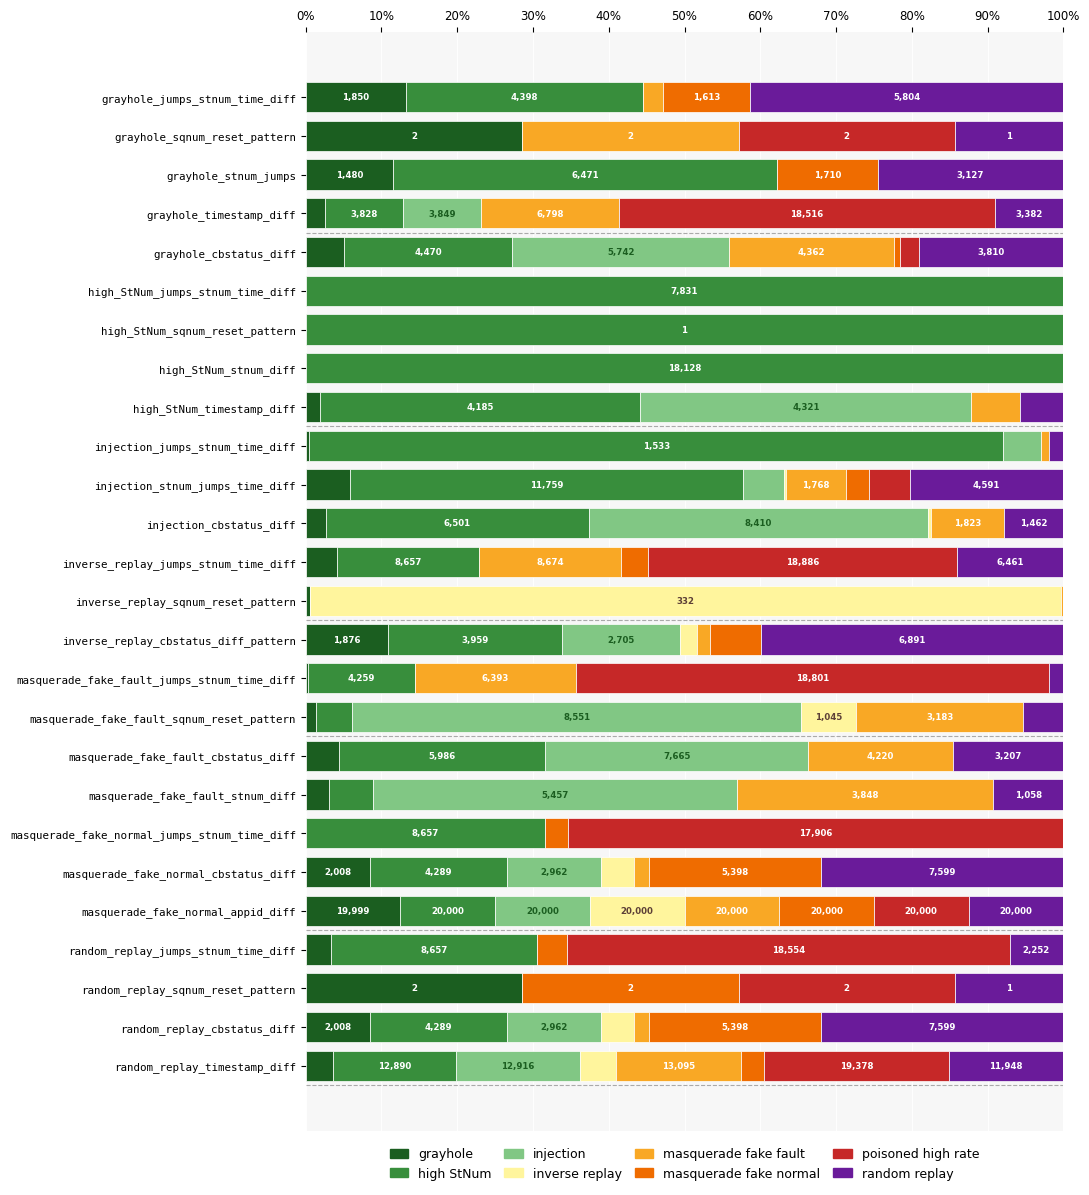

✓ Salvo em: matriz_regras_ataques_plot.png


In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Ajuste o caminho do CSV aqui ────────────────────────────────
CSV_PATH = "matriz_regras_ataques.csv"
OUTPUT   = "matriz_regras_ataques_plot.png"
# ────────────────────────────────────────────────────────────────

# ── Lê direto o CSV já computado pelo script anterior ───────────
df = pd.read_csv(CSV_PATH, index_col="Regra")
df = df.drop(columns=["normal"], errors="ignore")
df = df[df.sum(axis=1) > 0]
df_pct = df.div(df.sum(axis=1), axis=0) * 100

# ── Paleta: cores fixas para classes conhecidas,
#    fallback automático para qualquer classe nova ───────────────
KNOWN_COLORS = {
    "grayhole":               "#1b5e20",
    "high_StNum":             "#388e3c",
    "injection":              "#81c784",
    "inverse_replay":         "#fff59d",
    "masquerade_fake_fault":  "#f9a825",
    "masquerade_fake_normal": "#ef6c00",
    "poisoned_high_rate":     "#c62828",
    "random_replay":          "#6a1b9a",
}

KNOWN_TEXT = {
    "grayhole":               "white",
    "high_StNum":             "white",
    "injection":              "#1b5e20",
    "inverse_replay":         "#5d4037",
    "masquerade_fake_fault":  "white",
    "masquerade_fake_normal": "white",
    "poisoned_high_rate":     "white",
    "random_replay":          "white",
}

# Paleta de fallback para classes não mapeadas
_FALLBACK_PALETTE = plt.cm.tab20.colors  # 20 cores distintas
attacks = df_pct.columns.tolist()

def _luminance(hex_color):
    """Retorna luminância relativa (0–1) de uma cor hex."""
    c = hex_color.lstrip("#")
    r, g, b = (int(c[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(v): return v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4
    return 0.2126 * lin(r) + 0.7152 * lin(g) + 0.0722 * lin(b)

attack_colors = {}
text_color_map = {}
_fallback_idx = 0
for atk in attacks:
    if atk in KNOWN_COLORS:
        attack_colors[atk] = KNOWN_COLORS[atk]
        text_color_map[atk] = KNOWN_TEXT[atk]
    else:
        color = "#{:02x}{:02x}{:02x}".format(
            *[int(c * 255) for c in _FALLBACK_PALETTE[_fallback_idx % 20][:3]]
        )
        attack_colors[atk] = color
        text_color_map[atk] = "white" if _luminance(color) < 0.4 else "#333333"
        _fallback_idx += 1

# ── Plot ─────────────────────────────────────────────────────────
rules      = df_pct.index.tolist()
n_rules    = len(rules)
fig_height = max(10, n_rules * 0.48)

fig, ax = plt.subplots(figsize=(11, fig_height))
rule_labels = [r.replace("rule_", "") for r in rules]

lefts = np.zeros(n_rules)
for attack in attacks:
    color    = attack_colors[attack]
    txt_col  = text_color_map[attack]
    pct_vals = df_pct[attack].values
    abs_vals = df[attack].values
    ax.barh(
        range(n_rules), pct_vals, left=lefts,
        color=color, edgecolor="white", linewidth=0.5, height=0.78
    )
    for j, (pct, abv, l) in enumerate(zip(pct_vals, abs_vals, lefts)):
        if pct >= 7:
            ax.text(
                l + pct / 2, j, f"{int(abv):,}",
                ha="center", va="center",
                fontsize=6.2, color=txt_col, fontweight="bold"
            )
    lefts += pct_vals

ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)], fontsize=8.5)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)

ax.set_yticks(range(n_rules))
ax.set_yticklabels(rule_labels, fontsize=7.8, fontfamily="monospace")
ax.invert_yaxis()

# Separadores: calculados automaticamente a cada grupo de regras
# (mantém os hardcoded originais; para tornar dinâmico basta remover)
separators = [3.5, 8.5, 13.5, 16.5, 21.5, 25.5, 28.5]
for s in separators:
    if s < n_rules:
        ax.axhline(s, color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=2)

ax.set_axisbelow(True)
ax.xaxis.grid(True, color="white", linewidth=0.7)
ax.set_facecolor("#f7f7f7")
for spine in ax.spines.values():
    spine.set_visible(False)

patches = [
    mpatches.Patch(color=attack_colors[a], label=a.replace("_", " "))
    for a in attacks
]
ax.legend(
    handles=patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.055),
    ncol=4, fontsize=9,
    frameon=False,
    handlelength=1.5,
    columnspacing=1.0
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Salvo em: {OUTPUT}")

---
## 11. Considerações Finais

Este trabalho apresentou um pipeline orientado por LLM que automatiza a geração de regras de detecção para IDS baseados em especificação em subestações IEC 61850.

### Contribuições principais

- **Pipeline plug-and-play** end-to-end: do dataset rotulado às regras executáveis
- **Redução da dependência de especialistas** para criação manual de regras
- **Baixo overhead operacional**: regras Python leves adequadas a ambientes em tempo real
- **Reprodutibilidade**: parâmetros configuráveis e artefatos rastreáveis

### Limitações e trabalhos futuros

- Validação em hardware real de subestação (não apenas simulado)
- Avaliação com mais classes de ataque do dataset ERENO
- Comparação com abordagens de ML supervisionado
- Adaptação automática a novos padrões de ataque via atualização incremental

> **Repositório:** https://github.com/sequincozes/CounselorNode

---
## 12. Referências

- **Commission, I. E.** (2003). Communication networks and systems in substations - Part 8-1: SCSM. IET.

- **Hong, J. and Liu, C.** (2019). Intelligent electronic devices with collaborative intrusion detection systems. *IEEE Transactions on Smart Grid*, 10(1):271–281.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014a). Detection of Cyber Intrusions Using Network-Based Multicast Messages for Substation Automation. *ISGT*, IEEE.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014b). Integrated anomaly detection for cyber security of the substations. *IEEE Transactions on Smart Grid*, 5(4):1643–1653.

- **Kwon, Y. et al.** (2015). A behavior-based intrusion detection technique for smart grid infrastructure. *IEEE Eindhoven PowerTech*.

- **Malik, H., Alotaibi, M. A., and Almutairi, A.** (2022). Cyberattacks identification in IEC 61850 based substation using proximal SVM. *Journal of Intelligent & Fuzzy Systems*, 42(2):1213–1222.

- **Quincozes, S. E. et al.** (2021). A survey on intrusion detection and prevention systems in digital substations. *Computer Networks*, 184:107679.

- **Quincozes, S. E. et al.** (2022). ERENO: An Extensible Tool for Generating Realistic IEC–61850 Intrusion Detection Datasets. PhD thesis, UFF.

- **Yang, Y. et al.** (2016a). Intrusion detection system for IEC 61850 based smart substations. *IEEE PESGM*.

- **Yang, Y. et al.** (2016b). Multidimensional intrusion detection system for IEC 61850-based SCADA networks. *IEEE Transactions on Power Delivery*, 32(2):1068–1078.